Analysis of GHZ3 state

# import

In [1]:
# general import: 
import sys
import time
import os
import gc
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [3]:
# ML import:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split

In [4]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *
from mle import *

# F_q vs N_sample

In [5]:
def genera_dataset(p_exact, seed_data, n_samples=500):
    samples = sample_povm(p_exact, n_samples, seed=seed_data)
    return samples

In [6]:
def fit_mle_quantum(true_rho, samples, N):
    nll = make_nll(samples, N)

    dim = 2**N
    init_rho = np.eye(dim, dtype=complex) / dim
    p0 = rho_to_params(init_rho, N)

    m = Minuit(nll, *p0)
    m.errordef = Minuit.LIKELIHOOD
    m.print_level = 0
    m.migrad()
    if not m.valid:
        m.migrad()                                

    rho_mle = params_to_rho(np.array(m.values), N)
    p_mle = povm_probability(rho_mle, N)
    # fc    = classical_fidelity(p_exact, p_mle)
    fq    = quantum_fidelity(true_rho, rho_mle)

    return float(fq)

In [7]:
N = 3
qc = create_ghz_state(N)
rho_true = DensityMatrix(qc)
n_samples = 100
p_exact = povm_probability(rho_true.data, N)

In [8]:
B = 50                          # numero di dataset indipendenti (stats.md: 50-100)

rows = []
for b in range(B):
    samples = genera_dataset(p_exact=p_exact, seed_data=42 + b, n_samples=n_samples)
    fq_m = fit_mle_quantum(rho_true, samples, N)                                                  

    # stesso dataset b per entrambi => confronto PAIRED
    rows.append(dict(method='MLE', b=b, N=n_samples, F_q=fq_m))

    if b % 1 == 0:
        print(f"{b+1}/{B}  F_q: MLE={fq_m:.4f}")

# UN solo CSV, colonna 'b' = indice replica
df = pd.DataFrame(rows)
# df.to_csv(f'risultati_shot_N{n_samples}_B{B}_ghz.csv', index=False)
# print("\nSalvato. Righe:", len(df))

1/50  F_q: MLE=0.6129
2/50  F_q: MLE=0.7622
3/50  F_q: MLE=0.5042
4/50  F_q: MLE=0.5114
5/50  F_q: MLE=0.4573
6/50  F_q: MLE=0.7017
7/50  F_q: MLE=0.8703
8/50  F_q: MLE=0.6808
9/50  F_q: MLE=0.7605
10/50  F_q: MLE=0.6558
11/50  F_q: MLE=0.5569
12/50  F_q: MLE=0.8170
13/50  F_q: MLE=0.5640
14/50  F_q: MLE=0.5965
15/50  F_q: MLE=0.6221
16/50  F_q: MLE=0.5121
17/50  F_q: MLE=0.4773
18/50  F_q: MLE=0.6311
19/50  F_q: MLE=0.4903
20/50  F_q: MLE=0.6219
21/50  F_q: MLE=0.4357
22/50  F_q: MLE=0.5548
23/50  F_q: MLE=0.6146
24/50  F_q: MLE=0.5504
25/50  F_q: MLE=0.6036
26/50  F_q: MLE=0.7140
27/50  F_q: MLE=0.6444
28/50  F_q: MLE=0.5978
29/50  F_q: MLE=0.7270
30/50  F_q: MLE=0.5218
31/50  F_q: MLE=0.6990
32/50  F_q: MLE=0.7980
33/50  F_q: MLE=0.6445
34/50  F_q: MLE=0.7276
35/50  F_q: MLE=0.7684
36/50  F_q: MLE=0.4166
37/50  F_q: MLE=0.6527
38/50  F_q: MLE=0.6639
39/50  F_q: MLE=0.5437
40/50  F_q: MLE=0.5920
41/50  F_q: MLE=0.6502
42/50  F_q: MLE=0.6051
43/50  F_q: MLE=0.4984
44/50  F_q: MLE=0.56

In [23]:
tab = df.pivot_table(index='b', columns='method', values='F_q')
print(np.mean(tab.values),
np.std(tab.values))

0.6149137618346199 0.10843070379700451


# $F_c$ vs $N_{sample}$

In [ ]:
def genera_dataset(p_exact, seed_data, n_samples=500):
    samples = sample_povm(p_exact, n_samples, seed=seed_data)
    return samples

In [ ]:
def fit_mle(p_exact, samples, N):
    nll = make_nll(samples, N)

    dim = 2**N
    init_rho = np.eye(dim, dtype=complex) / dim
    p0 = rho_to_params(init_rho, N)

    m = Minuit(nll, *p0)
    m.errordef = Minuit.LIKELIHOOD
    m.print_level = 0
    m.migrad()
    if not m.valid:
        m.migrad()                                

    rho_mle = params_to_rho(np.array(m.values), N)
    p_mle = povm_probability(rho_mle, N)
    fc    = classical_fidelity(p_exact, p_mle)

    return float(fc)

In [ ]:
def fit_vae(p_exact, samples, N, n_gen=50_000):
    onehot_samples = samples_to_onehot(samples, N)

    X_train, X_test = train_test_split(onehot_samples, test_size=0.2,
                                       random_state=42)

    LATENT_DIM = 16
    HIDDEN_DIM = 96
    WARMUP_EPOCHS = 50
    TOTAL_EPOCHS = 500
    BATCH_SIZE = 100
    LEARNING_RATE = 1e-3
    BETA_MAX = 0.85

    vae = VAE(n_qubits=N, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
    vae.build(input_shape=(None, 4*N))

    callbacks = [
        KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
        keras.callbacks.EarlyStopping(
            monitor='val_reconstruction_loss', mode='min', patience=50,
            restore_best_weights=True, start_from_epoch=WARMUP_EPOCHS),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_reconstruction_loss', mode='min',
            factor=0.5, patience=20, min_lr=1e-6),
    ]
    vae.fit(X_train, X_train, epochs=TOTAL_EPOCHS, batch_size=BATCH_SIZE,
            validation_data=(X_test, X_test), callbacks=callbacks, verbose=0)

    p_vae = vae.predict_dist(n_samples=n_gen, batch_size=50_000)
    fc = classical_fidelity(p_exact, p_vae)

    # libera grafo TF + RAM: in un kernel longevo clear_session() da solo non basta,
    # serve anche eliminare il modello e forzare il garbage collector.
    del vae
    keras.backend.clear_session()
    gc.collect()
    return float(fc)

In [ ]:
N = 3
qc = create_ghz_state(N)
rho_true = DensityMatrix(qc)
n_samples = 10000
p_exact = povm_probability(rho_true.data, N)

In [ ]:
B = 50                          # numero di dataset indipendenti (stats.md: 50-100)
N_GEN = 100_000                   # campioni VAE per stimare p_vae (>> n_samples, vedi stats.md)  

rows = []
for b in range(B):
    samples = genera_dataset(p_exact=p_exact, seed_data=42 + b, n_samples=n_samples)
    fc_m = fit_mle(p_exact, samples, N)                                                  
    fc_v = fit_vae(p_exact, samples, N, n_gen=N_GEN)     

    # stesso dataset b per entrambi => confronto PAIRED
    rows.append(dict(method='MLE', b=b, N=n_samples, F_c=fc_m))
    rows.append(dict(method='VAE', b=b, N=n_samples, F_c=fc_v))

    if b % 1 == 0:
        print(f"{b+1}/{B}  F_c: MLE={fc_m:.4f}  VAE={fc_v:.4f}")

# UN solo CSV, colonna 'b' = indice replica
df = pd.DataFrame(rows)
df.to_csv(f'risultati_shot_N{n_samples}_B{B}_ghz.csv', index=False)
print("\nSalvato. Righe:", len(df))

1/50  F_c: MLE=0.9997  VAE=0.9900
2/50  F_c: MLE=0.9998  VAE=0.9910
3/50  F_c: MLE=0.9996  VAE=0.9912
4/50  F_c: MLE=0.9996  VAE=0.9913
5/50  F_c: MLE=0.9997  VAE=0.9920
6/50  F_c: MLE=0.9994  VAE=0.9910
7/50  F_c: MLE=0.9997  VAE=0.9883
8/50  F_c: MLE=0.9998  VAE=0.9915
9/50  F_c: MLE=0.9995  VAE=0.9910
10/50  F_c: MLE=0.9998  VAE=0.9909
11/50  F_c: MLE=0.9996  VAE=0.9917
12/50  F_c: MLE=0.9997  VAE=0.9908
13/50  F_c: MLE=0.9996  VAE=0.9913
14/50  F_c: MLE=0.9995  VAE=0.9886
15/50  F_c: MLE=0.9997  VAE=0.9906
16/50  F_c: MLE=0.9996  VAE=0.9918
17/50  F_c: MLE=0.9997  VAE=0.9909
18/50  F_c: MLE=0.9997  VAE=0.9907
19/50  F_c: MLE=0.9996  VAE=0.9916
20/50  F_c: MLE=0.9997  VAE=0.9910
21/50  F_c: MLE=0.9997  VAE=0.9891
22/50  F_c: MLE=0.9997  VAE=0.9921
23/50  F_c: MLE=0.9997  VAE=0.9909
24/50  F_c: MLE=0.9996  VAE=0.9913
25/50  F_c: MLE=0.9996  VAE=0.9916
26/50  F_c: MLE=0.9997  VAE=0.9902
27/50  F_c: MLE=0.9998  VAE=0.9921
28/50  F_c: MLE=0.9998  VAE=0.9893
29/50  F_c: MLE=0.9997  VAE=0

In [ ]:
# --- Setup e confronto appaiato (errore sulla media, CLT, t-test, bootstrap) ---
# Sorgente: i CSV salvati (B=50 dataset indipendenti per ogni N_sample, qubit fissi = 3).
# Cella autosufficiente: non dipende dalla run in-memory delle celle precedenti.

import glob
from scipy import stats

# load
paths = sorted(glob.glob("risultati_shot_N*_B50_ghz.csv"))
df_cmp = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
df_cmp = df_cmp.rename(columns={'N': 'N_sample'})
print("loaded files:", paths)
# print("N_sample disponibili:", sorted(df_cmp.N_sample.unique()), "| B =", df_cmp.b.nunique())

rows = []
for Ns in sorted(df_cmp.N_sample.unique()):
    piv = df_cmp[df_cmp.N_sample == Ns].pivot_table(index='b', columns='method', values='F_c')
    d = (piv['VAE'] - piv['MLE']).values          # B=50 differenze appaiate; < 0 => MLE meglio

    B    = len(d)
    mean = d.mean()
    sem  = d.std(ddof=1) / np.sqrt(B)             # errore sulla media
    t, p = stats.ttest_rel(piv['VAE'], piv['MLE'])  # t appaiato: t = mean/sem = significativita in sigma
    ci_g = (mean - 1.96 * sem, mean + 1.96 * sem)   # CI95 gaussiano (giustificato dal CLT)
    # cross-check senza assumere gaussianita: bootstrap sulla media
    ci_b = stats.bootstrap((d,), np.mean, confidence_level=0.95,
                           n_resamples=10000, method='percentile',
                           random_state=0).confidence_interval

    rows.append(dict(N_sample=int(Ns), B=B, mean_delta=mean, sem_delta=sem,
                     sigma=abs(t), p_value=p,
                     ci_lo=ci_g[0], ci_hi=ci_g[1],
                     boot_lo=ci_b.low, boot_hi=ci_b.high,
                     frac_VAE_meglio=(d > 0).mean()))

res = pd.DataFrame(rows)   # nota: colonna 'sem_delta' (non 'sem': collide con DataFrame.sem())

# tabella leggibile: l'effect size (media Delta) e' il risultato, p-value e sigma confermano
disp = pd.DataFrame({
    "N_sample":        res.N_sample,
    "media Delta":     res.mean_delta.map(lambda x: f"{x:+.4f}"),
    "SEM":             res.sem_delta.map(lambda x: f"{x:.4f}"),
    "signif. (sigma)": res.sigma.map(lambda x: f"{x:.0f}"),
    "p-value (t)":     res.p_value.map(lambda x: f"{x:.1e}"),
    "CI95 gauss":      res.apply(lambda r: f"[{r.ci_lo:+.4f}, {r.ci_hi:+.4f}]", axis=1),
    "CI95 bootstrap":  res.apply(lambda r: f"[{r.boot_lo:+.4f}, {r.boot_hi:+.4f}]", axis=1),
    "VAE vince":       res.frac_VAE_meglio.map(lambda x: f"{x:.0%}"),
})
print(disp.to_string(index=False))

File caricati: ['risultati_shot_N10000_B50_ghz.csv', 'risultati_shot_N1000_B50_ghz.csv', 'risultati_shot_N100_B50_ghz.csv', 'risultati_shot_N200_B50_ghz.csv', 'risultati_shot_N5000_B50_ghz.csv', 'risultati_shot_N500_B50_ghz.csv']
N_sample disponibili: [np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(5000), np.int64(10000)] | B = 50
 N_sample media Delta    SEM signif. (sigma) p-value (t)         CI95 gauss     CI95 bootstrap VAE vince
      100     -0.0188 0.0011              16     1.5e-21 [-0.0210, -0.0166] [-0.0210, -0.0166]        4%
      200     -0.0215 0.0006              37     2.3e-37 [-0.0226, -0.0204] [-0.0226, -0.0204]        0%
      500     -0.0194 0.0003              60     1.7e-47 [-0.0201, -0.0188] [-0.0201, -0.0188]        0%
     1000     -0.0170 0.0003              55     7.0e-46 [-0.0176, -0.0164] [-0.0176, -0.0164]        0%
     5000     -0.0112 0.0003              43     1.3e-40 [-0.0117, -0.0107] [-0.0117, -0.0107]        0%
    10000     

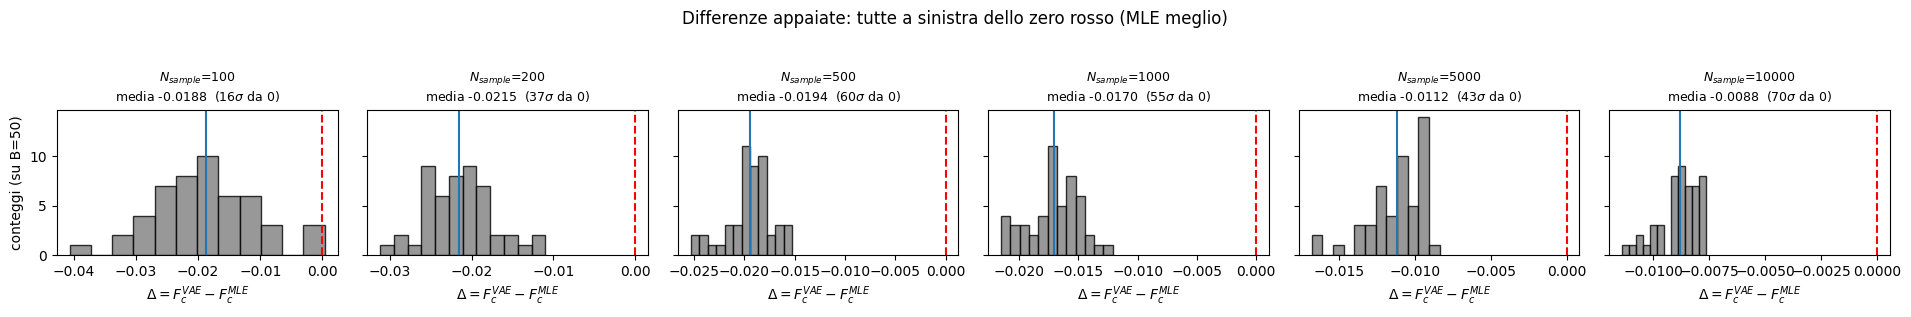

La media di B=50 differenze e' gaussiana per il CLT => t-test e CI gaussiano sono giustificati,
senza bisogno di un test di normalita. Zero (rosso) e media (blu) sono ben separati.


In [16]:
# --- Distribuzione delle differenze appaiate: istogrammi (giustificano la gaussiana via CLT) ---
Ns_list = sorted(df_cmp.N_sample.unique())
fig, axes = plt.subplots(1, len(Ns_list), figsize=(3.2 * len(Ns_list), 3.0), sharey=True)
for ax, Ns in zip(np.atleast_1d(axes), Ns_list):
    piv = df_cmp[df_cmp.N_sample == Ns].pivot_table(index='b', columns='method', values='F_c')
    d = (piv['VAE'] - piv['MLE']).values
    ax.hist(d, bins=12, color='C7', edgecolor='k', alpha=.8)
    ax.axvline(0, color='r', lw=1.5, ls='--')       # zero = nessuna differenza
    ax.axvline(d.mean(), color='C0', lw=1.5)         # media osservata
    r = res.loc[res.N_sample == Ns].iloc[0]
    ax.set_title(f"$N_{{sample}}$={Ns}\nmedia {r.mean_delta:+.4f}  ({r.sigma:.0f}$\\sigma$ da 0)", fontsize=9)
    ax.set_xlabel(r"$\Delta = F_c^{VAE}-F_c^{MLE}$")
np.atleast_1d(axes)[0].set_ylabel("conteggi (su B=50)")
fig.suptitle("Differenze appaiate: tutte a sinistra dello zero rosso (MLE meglio)", y=1.04)
fig.tight_layout()
plt.show()

print("La media di B=50 differenze e' gaussiana per il CLT => t-test e CI gaussiano sono giustificati,")
print("senza bisogno di un test di normalita. Zero (rosso) e media (blu) sono ben separati.")

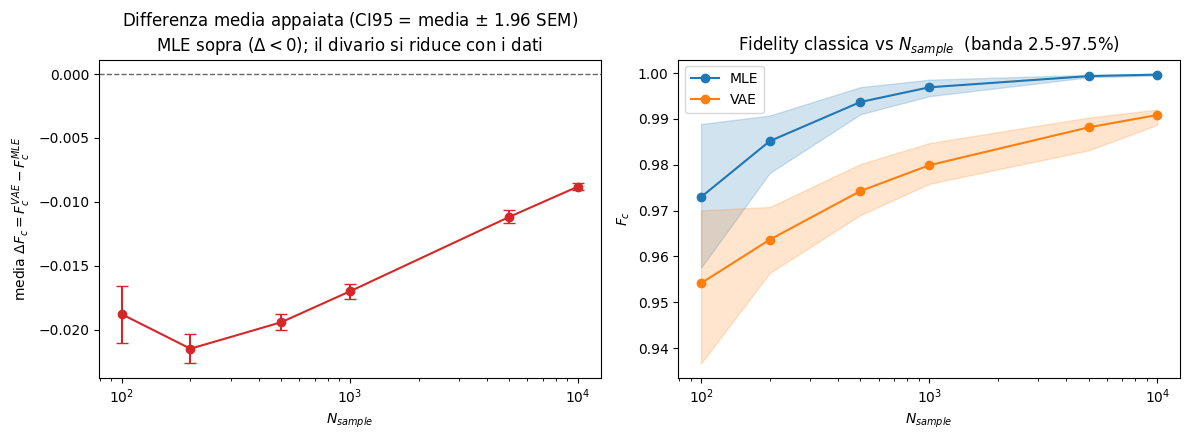

In [17]:
# --- Visualizzazione: differenza media e fidelity vs N_sample ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# (sinistra) media di Delta con CI95 gaussiano (media +/- 1.96 SEM), vs N_sample
ax1.axhline(0, color='k', lw=1, ls='--', alpha=.6)
ax1.errorbar(res.N_sample, res.mean_delta, yerr=1.96 * res.sem_delta.values,
             fmt='o-', capsize=4, color='C3')
ax1.set_xscale('log')
ax1.set_xlabel(r"$N_{sample}$")
ax1.set_ylabel(r"media $\Delta F_c = F_c^{VAE} - F_c^{MLE}$")
ax1.set_title("Differenza media appaiata (CI95 = media $\\pm$ 1.96 SEM)\nMLE sopra ($\\Delta<0$); il divario si riduce con i dati")

# (destra) F_c per metodo con banda 2.5-97.5 percentile delle B=50 repliche (spread Monte Carlo)
for met, c in [('MLE', 'C0'), ('VAE', 'C1')]:
    g = df_cmp[df_cmp.method == met].groupby('N_sample')['F_c']
    ax2.plot(g.mean().index, g.mean().values, 'o-', color=c, label=met)
    ax2.fill_between(g.mean().index, g.quantile(.025).values, g.quantile(.975).values,
                     color=c, alpha=.2)
ax2.set_xscale('log')
ax2.set_xlabel(r"$N_{sample}$")
ax2.set_ylabel(r"$F_c$")
ax2.set_title("Fidelity classica vs $N_{sample}$  (banda 2.5-97.5%)")
ax2.legend()

fig.tight_layout()
plt.show()